***Inserting data to customers table***

In [314]:
# import pandas as pd
# import mysql.connector as cor

# db_config = {
#     'user': 'root',
#     'password': 'Kash@123',
#     'host': 'localhost',
#     'database': 'ecom_analysis'
# }

# conn = cor.connect(**db_config)
# cursor = conn.cursor()

# # Customer table
# df = pd.read_csv('customer.csv')

# insert_query = """
# INSERT INTO customer (customer_id,name,city,email,phone_no,address,pin_code)
# VALUES (%s, %s, %s, %s, %s, %s, %s)
# """

# for index, row in df.iterrows():
#     cursor.execute(insert_query, tuple(row))

# conn.commit()

# cursor.close()
# conn.close()


***Inserting data to Products table***

In [315]:
# import pandas as pd
# import mysql.connector as cor

# db_config = {
#     'user': 'root',
#     'password': 'Kash@123',
#     'host': 'localhost',
#     'database': 'ecom_analysis'
# }

# conn = cor.connect(**db_config)
# cursor = conn.cursor()

# # Customer table
# df = pd.read_csv('products.csv')

# insert_query = """
# INSERT INTO product (product_id,product_name,category,sub_category,original_price,selling_price,stock)
# VALUES (%s, %s, %s, %s, %s, %s, %s)
# """

# for index, row in df.iterrows():
#     cursor.execute(insert_query, tuple(row))

# conn.commit()

# cursor.close()
# conn.close()

***Inserting data into Orders table***

In [316]:
# import pandas as pd
# import mysql.connector as cor

# db_config = {
#     'user': 'root',
#     'password': 'Kash@123',
#     'host': 'localhost',
#     'database': 'ecom_analysis'
# }

# conn = cor.connect(**db_config)
# cursor = conn.cursor()

# # Customer table
# df = pd.read_csv('Order.csv')

# insert_query = """
# INSERT INTO order_details (order_id,customer_id,product_id,quantity,total_price,payment_mode,order_date,order_status)
# VALUES (%s, %s, %s, %s, %s, %s, %s,%s)
# """

# for index, row in df.iterrows():
#     cursor.execute(insert_query, tuple(row))

# conn.commit()

# cursor.close()
# conn.close()

In [317]:
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    user = 'root',
    password = 'Kash@123',
    host = 'localhost',
    database = 'ecom_analysis'
)
cursor = connection.cursor()


In [318]:
cursor.execute('SELECT * FROM customer')
customer_data = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in
cursor.description])
customer_data.head()

,customer_id,name,city,email,phone_no,address,pin_code
0,3a253b,John Doe,Springfield,john.doe@example.com,555-1234,123 Elm St,62701
1,3a253c,Jane Smith,Metropolis,jane.smith@example.com,555-5678,456 Oak Ave,63101
2,3a253d,Bob Johnson,Gotham,bob.johnson@example.com,555-8765,789 Pine Rd,54101
3,3a253e,Alice Brown,Star City,alice.brown@example.com,555-4321,101 Maple Dr,78901
4,3a253f,Michael Davis,Smallville,michael.davis@example.com,555-6789,202 Birch Blvd,43001


In [319]:
cursor.execute('SELECT * FROM product')
product_data = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in
cursor.description])

product_data.head()

,product_id,product_name,category,sub_category,original_price,selling_price,stock
0,p001,Wireless Mouse,Electronics,Computer Accessories,25.99,18.99,150
1,p002,USB Keyboard,Electronics,Computer Accessories,39.99,29.99,200
2,p003,Smartphone Case,Electronics,Mobile Accessories,15.99,10.99,300
3,p004,LED Monitor,Electronics,Computer Peripherals,199.99,159.99,50
4,p005,External Hard Drive,Electronics,Storage Devices,89.99,69.99,80


In [320]:
cursor.execute('SELECT * FROM order_details')
order_data = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in
cursor.description])

order_data.head()

,order_id,customer_id,product_id,quantity,total_price,payment_mode,order_date,order_status
0,1,3a253b,p001,2.0,37.98,Credit Card,2024-08-01 14:23:00,delivered
1,2,3a253c,p002,1.0,29.99,PayPal,2024-08-02 09:45:00,delivered
2,3,3a253d,p003,3.0,32.97,Debit Card,2024-08-03 11:10:00,not delivered
3,4,3a253e,p004,1.0,159.99,Credit Card,2024-08-04 16:35:00,delivered
4,5,3a253f,p005,2.0,139.98,PayPal,2024-08-05 12:05:00,delivered


In [321]:
import matplotlib.pyplot as plt

***Total number of customers by city***

In [322]:
import pandas as pd
import mysql.connector as cor
import matplotlib.pyplot as plt

# Database configuration
conn = cor.connect(
    user = 'root',
    password = 'Kash@123',
    host = 'localhost',
    database = 'ecom_analysis'
)

C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\1974824992.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


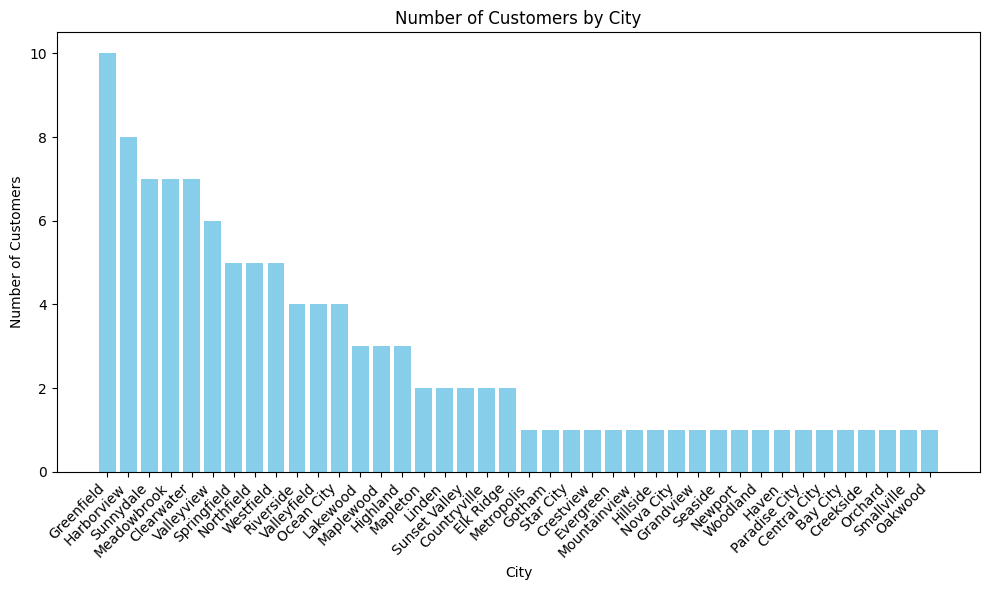

In [323]:
query = """
SELECT city, COUNT(*) AS total_customers
FROM customer
GROUP BY city
ORDER BY total_customers DESC
"""

# Fetch the data into a DataFrame
df = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(df['city'], df['total_customers'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\1929469542.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


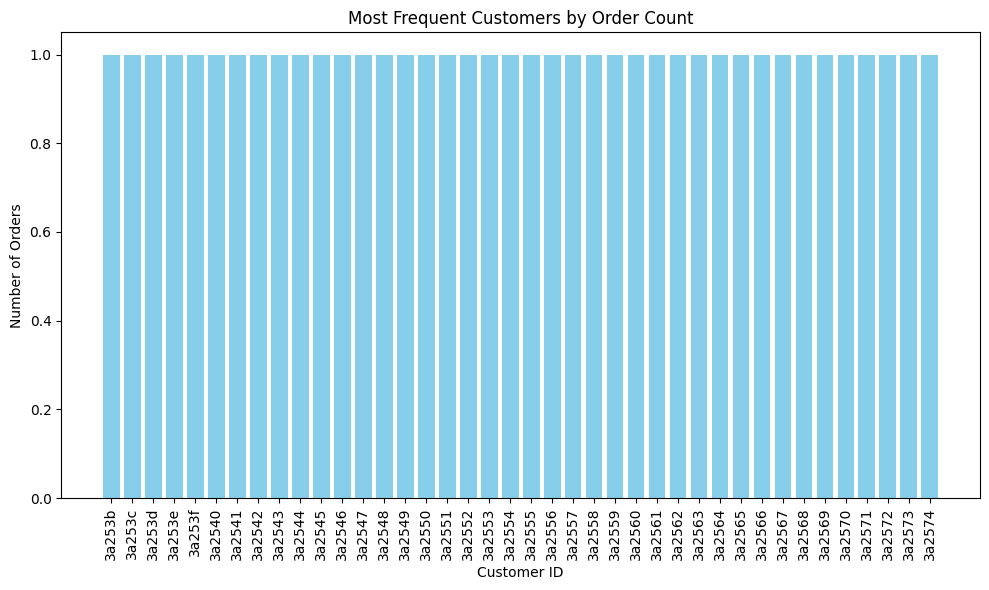

In [324]:
query = """
SELECT customer_id, COUNT(*) AS order_count
FROM order_details
GROUP BY customer_id
ORDER BY order_count DESC
"""

# Fetch the data into a DataFrame
df = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(df['customer_id'], df['order_count'], color='skyblue')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.title('Most Frequent Customers by Order Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\3985206664.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


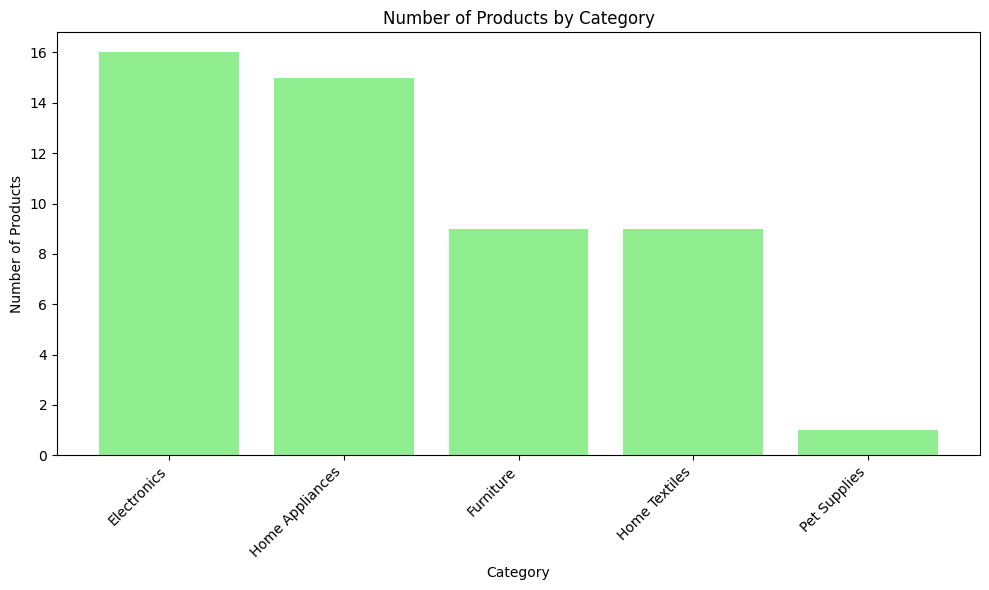

In [325]:
query = """
SELECT category, COUNT(*) AS total_products
FROM product
GROUP BY category
ORDER BY total_products DESC
"""

# Fetch the data into a DataFrame
df = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Plot the data
plt.figure(figsize=(10, 6))
plt.bar(df['category'], df['total_products'], color='lightgreen')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.title('Number of Products by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2449423724.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


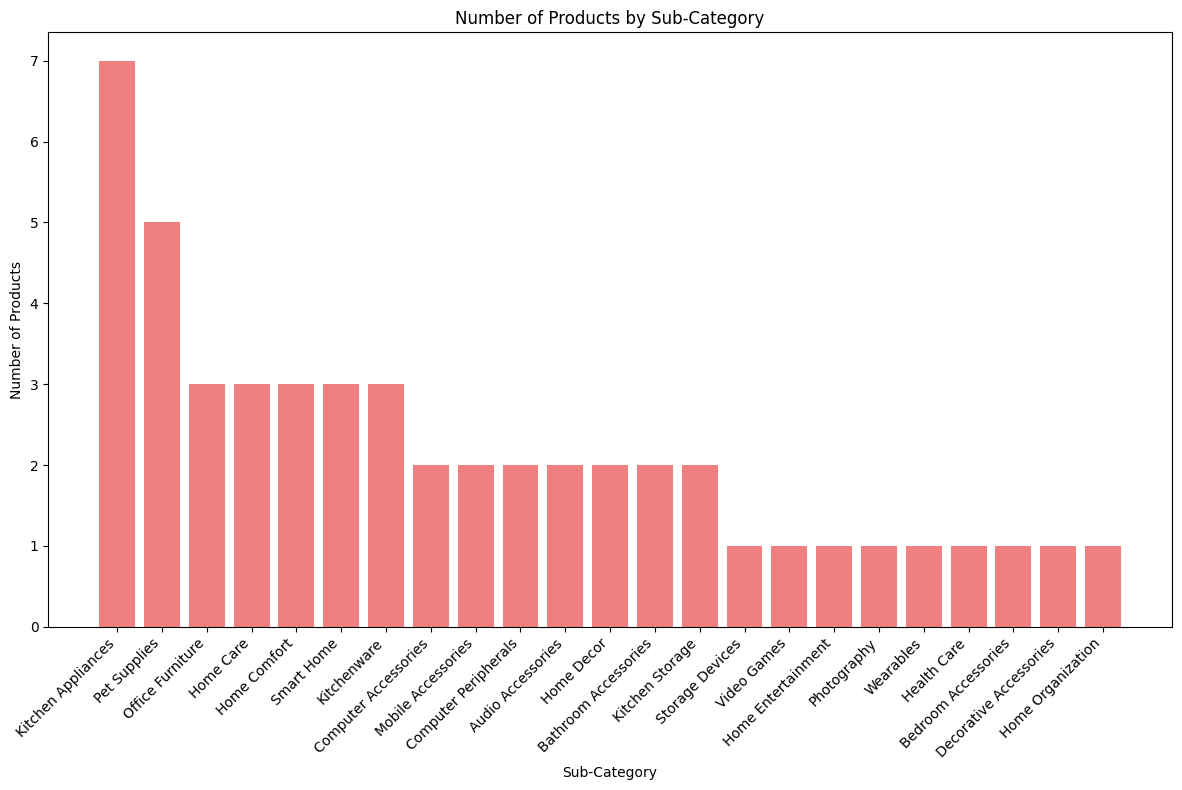

In [326]:
query = """
SELECT sub_category, COUNT(*) AS total_products
FROM product
GROUP BY sub_category
ORDER BY total_products DESC
"""

# Fetch the data into a DataFrame
df = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Plot the data
plt.figure(figsize=(12, 8))
plt.bar(df['sub_category'], df['total_products'], color='lightcoral')
plt.xlabel('Sub-Category')
plt.ylabel('Number of Products')
plt.title('Number of Products by Sub-Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


   product_id        product_name  stock
0        p015            Smart TV     20
1        p016      Digital Camera     25
2        p035  Compact Dishwasher     25
3        p014      Vacuum Cleaner     30
4        p022          Smartwatch     35
5        p049         Pet Carrier     35
6        p008      Gaming Console     40
7        p007        Office Chair     45
8        p031      Microwave Oven     45
9        p037     Security Camera     45
10       p047            Cat Tree     45


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\729180706.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_low_stock = pd.read_sql(query, conn)


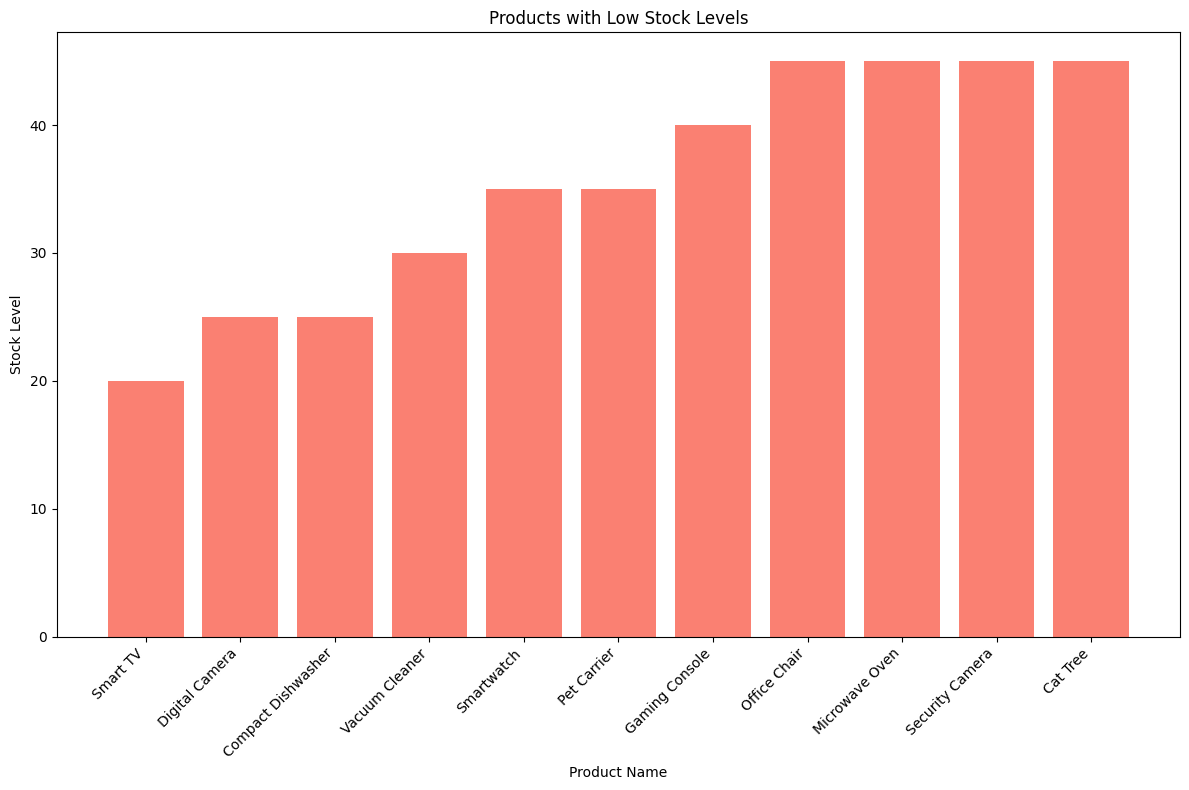

In [327]:
low_stock_threshold = 50 

query = f"""
SELECT product_id, product_name, stock
FROM product
WHERE stock < {low_stock_threshold}
ORDER BY stock ASC
"""

# Fetch the data into a DataFrame
df_low_stock = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Display the results
print(df_low_stock)

# Optionally, you can also plot the results
import matplotlib.pyplot as plt

# Plot the data
plt.figure(figsize=(12, 8))
plt.bar(df_low_stock['product_name'], df_low_stock['stock'], color='salmon')
plt.xlabel('Product Name')
plt.ylabel('Stock Level')
plt.title('Products with Low Stock Levels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\3889995955.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_price_stats = pd.read_sql(query, conn)


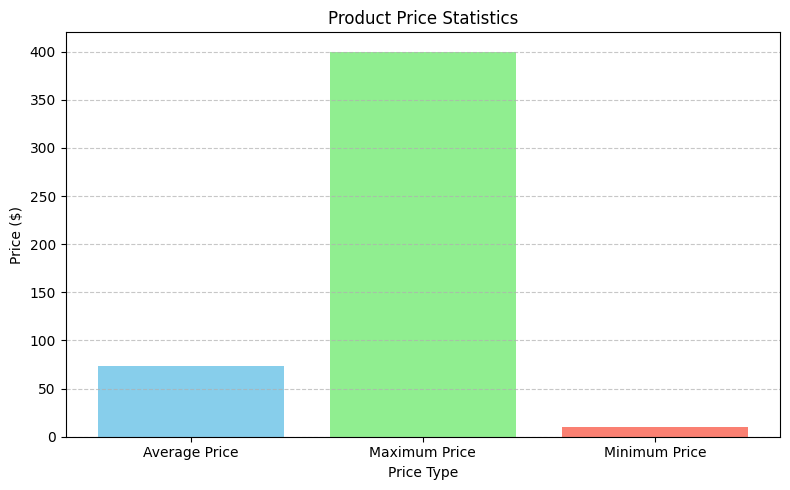

In [328]:
query = """
SELECT 
    AVG(selling_price) AS average_price,
    MAX(selling_price) AS maximum_price,
    MIN(selling_price) AS minimum_price
FROM product
"""

# Fetch the data into a DataFrame
df_price_stats = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Extract values for plotting
average_price = df_price_stats['average_price'][0]
maximum_price = df_price_stats['maximum_price'][0]
minimum_price = df_price_stats['minimum_price'][0]

# Data for plotting
labels = ['Average Price', 'Maximum Price', 'Minimum Price']
values = [average_price, maximum_price, minimum_price]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=['skyblue', 'lightgreen', 'salmon'])
plt.xlabel('Price Type')
plt.ylabel('Price ($)')
plt.title('Product Price Statistics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2192052183.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_products = pd.read_sql(query, conn)


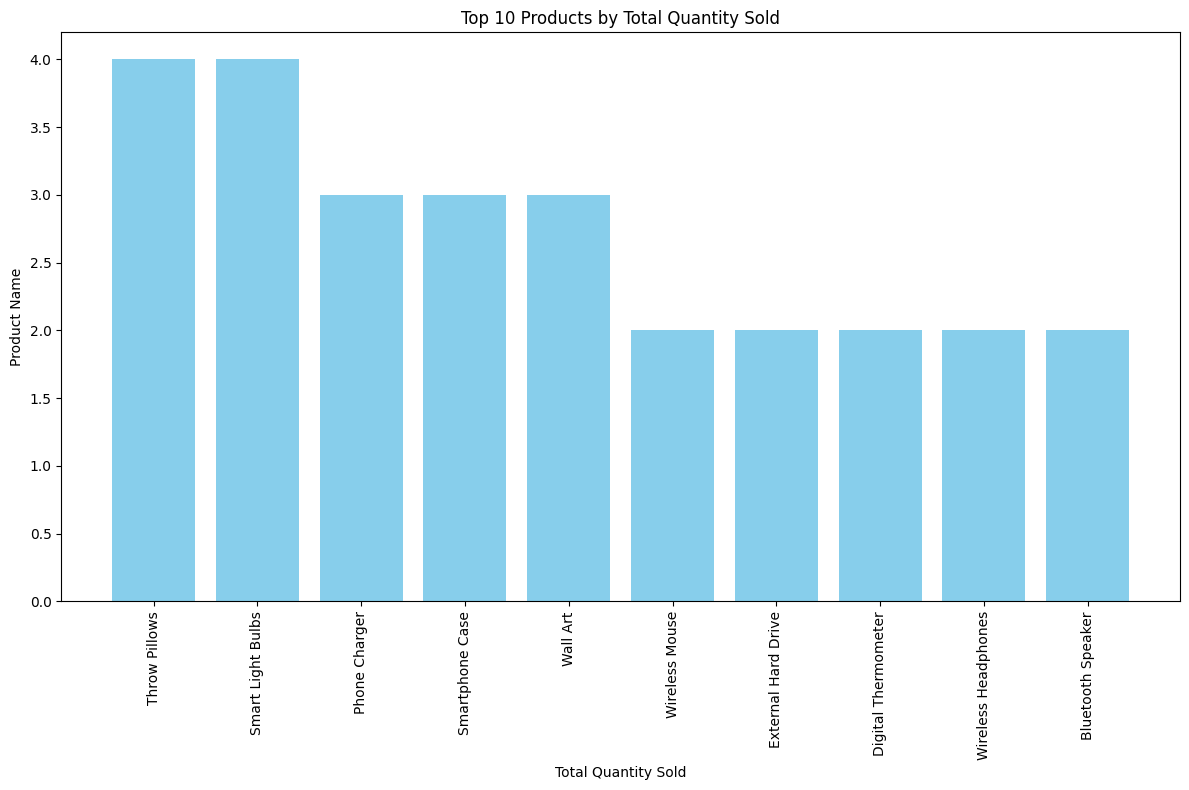

In [329]:
query = """
SELECT 
    p.product_id,
    p.product_name,
    SUM(od.quantity) AS total_quantity
FROM 
    order_details od
JOIN 
    product p ON od.product_id = p.product_id
GROUP BY 
    p.product_id, p.product_name
ORDER BY 
    total_quantity DESC
LIMIT 10;
"""

# Fetch the data into a DataFrame
df_top_products = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Plot
plt.figure(figsize=(12, 8))
plt.bar(df_top_products['product_name'], df_top_products['total_quantity'], color='skyblue')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')
plt.xticks(rotation = 90)
plt.title('Top 10 Products by Total Quantity Sold')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\4002616202.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_status_distribution = pd.read_sql(query, conn)


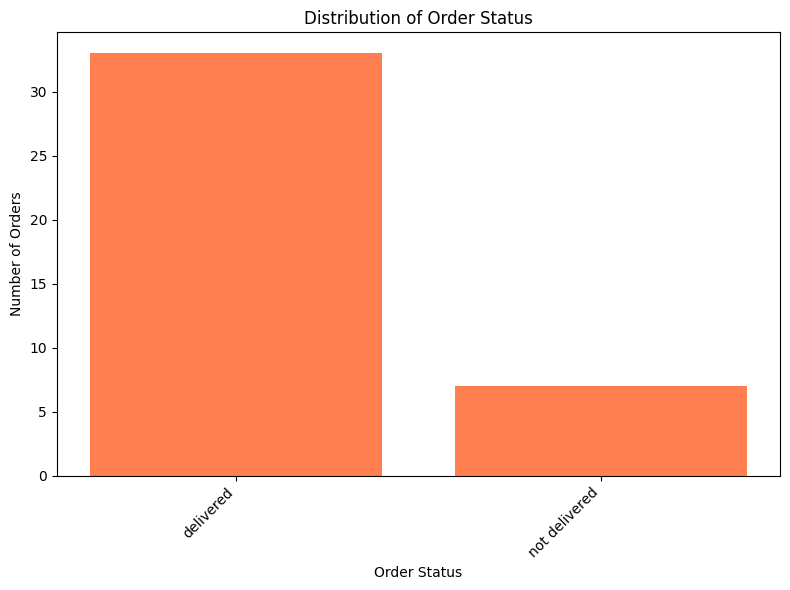

In [330]:
query = """
SELECT 
    order_status,
    COUNT(*) AS count
FROM 
    order_details
GROUP BY 
    order_status;
"""

# Fetch the data into a DataFrame
df_status_distribution = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(df_status_distribution['order_status'], df_status_distribution['count'], color='coral')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2242410479.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_popular_products = pd.read_sql(query, conn)
C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2242410479.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product_names = pd.read_sql(product_names_query, conn)


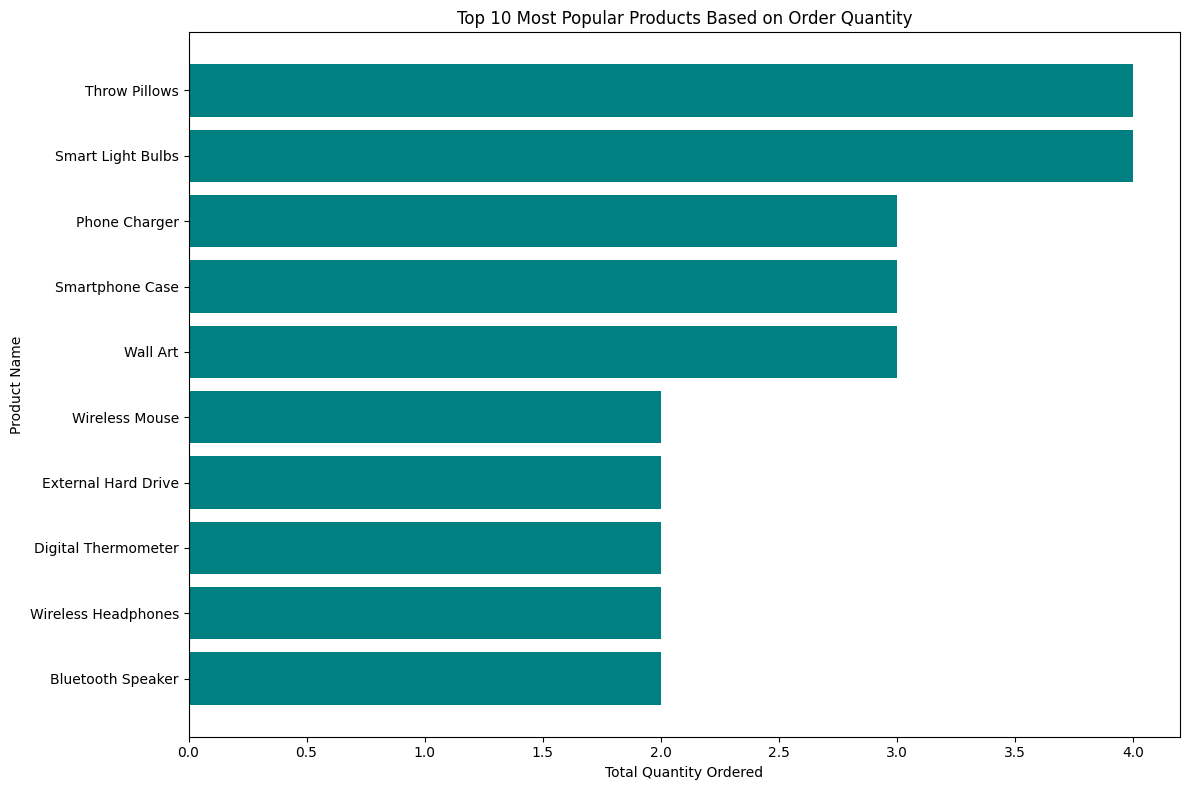

In [331]:
query = """
SELECT 
    product_id,
    SUM(quantity) AS total_quantity
FROM 
    order_details
GROUP BY 
    product_id
ORDER BY 
    total_quantity DESC
LIMIT 10;
"""

# Fetch the data into a DataFrame
df_popular_products = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Load product names for better readability (assuming a products table exists)
product_names_query = """
SELECT
    product_id,
    product_name
FROM
    product;
"""

# Fetch the product names
df_product_names = pd.read_sql(product_names_query, conn)

# Merge product names with popular products
df_popular_products = df_popular_products.merge(df_product_names, on='product_id')

# Plot
plt.figure(figsize=(12, 8))
plt.barh(df_popular_products['product_name'], df_popular_products['total_quantity'], color='teal')
plt.xlabel('Total Quantity Ordered')
plt.ylabel('Product Name')
plt.title('Top 10 Most Popular Products Based on Order Quantity')
plt.gca().invert_yaxis()  # Invert y-axis to show the highest quantities on top
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\1543233495.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_revenue = pd.read_sql(query, conn)
C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\1543233495.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product_names = pd.read_sql(product_names_query, conn)


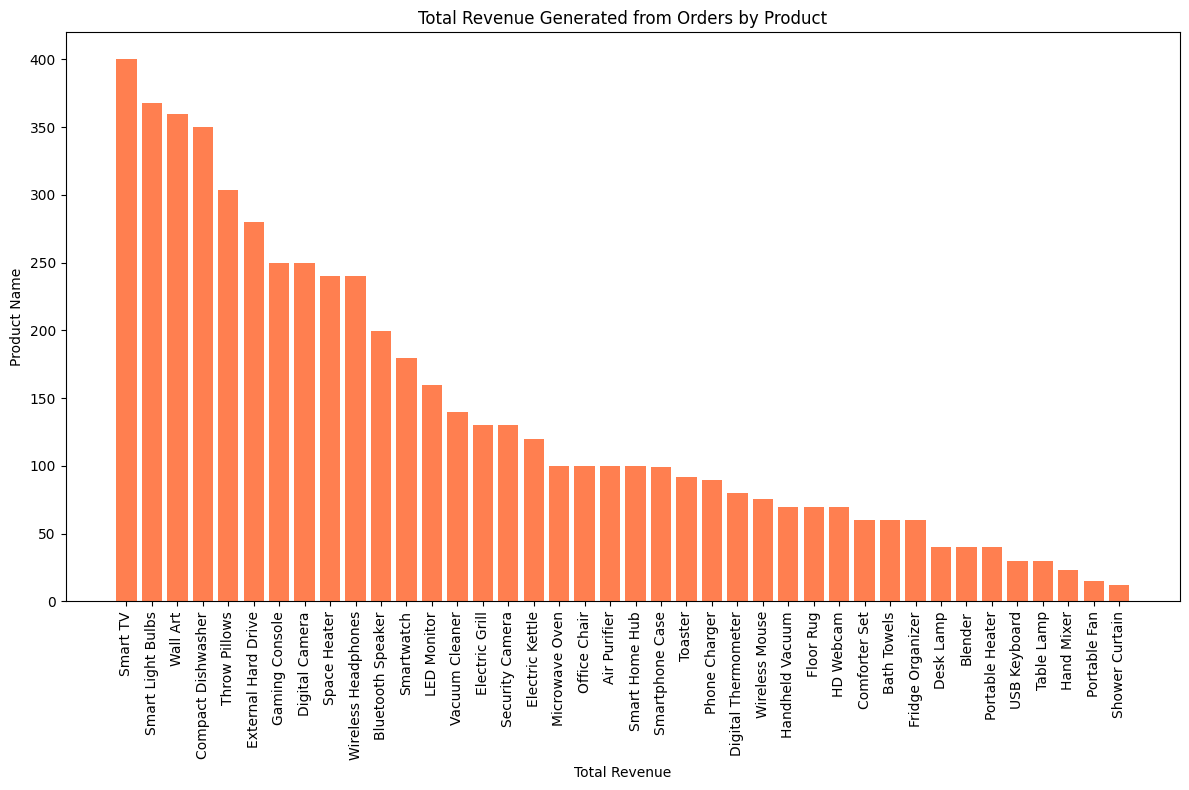

In [332]:
query = """
SELECT 
    product_id,
    SUM(quantity * total_price) AS total_revenue
FROM 
    order_details
GROUP BY 
    product_id
ORDER BY 
    total_revenue DESC;
"""

# Fetch the data into a DataFrame
df_revenue = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Load product names for better readability (assuming a products table exists)
product_names_query = """
SELECT
    product_id,
    product_name
FROM
    product;
"""

# Fetch the product names
df_product_names = pd.read_sql(product_names_query, conn)

# Merge product names with revenue data
df_revenue = df_revenue.merge(df_product_names, on='product_id')

# Plot
plt.figure(figsize=(12, 8))
plt.bar(df_revenue['product_name'], df_revenue['total_revenue'], color='coral')
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.xticks(rotation = 90)
plt.title('Total Revenue Generated from Orders by Product')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2900063872.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_revenue_by_category = pd.read_sql(query, conn)


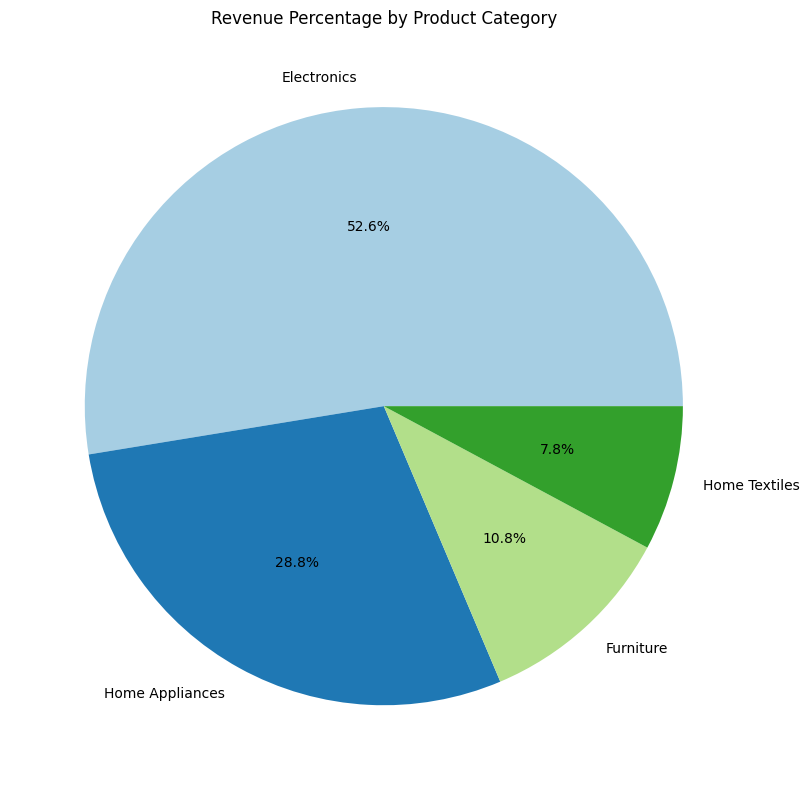

In [333]:
query = """
SELECT 
    p.category AS category,
    SUM(od.quantity * od.total_price) AS total_revenue
FROM 
    order_details od
JOIN 
    product p ON od.product_id = p.product_id
GROUP BY 
    p.category
ORDER BY 
    total_revenue DESC;
"""

# Fetch the data into a DataFrame
df_revenue_by_category = pd.read_sql(query, conn)

# Close the database connection
# conn.close()

# Calculate the total revenue
total_revenue = df_revenue_by_category['total_revenue'].sum()

# Calculate the percentage for each category
df_revenue_by_category['percentage'] = (df_revenue_by_category['total_revenue'] / total_revenue) * 100

# Plot
plt.figure(figsize=(10, 8))
plt.pie(df_revenue_by_category['percentage'], labels=df_revenue_by_category['category'], autopct='%1.1f%%', colors=plt.cm.Paired(range(len(df_revenue_by_category))))
plt.title('Revenue Percentage by Product Category')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2607807431.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


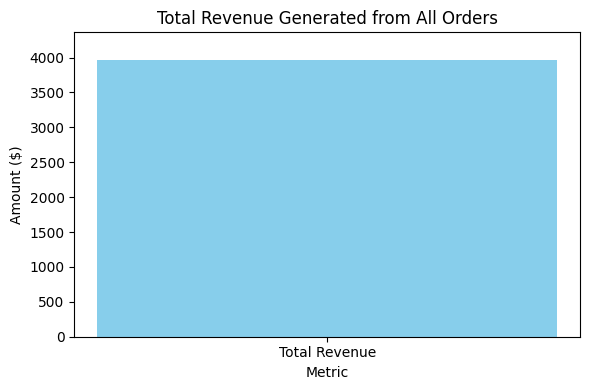

In [334]:
query = """
SELECT SUM(total_price) AS total_revenue
FROM order_details;
"""

# Execute the query and fetch the result
df = pd.read_sql(query, conn)
total_revenue = df['total_revenue'][0]

# Close the connection
# conn.close()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['Total Revenue'], [total_revenue], color='skyblue')
plt.xlabel('Metric')
plt.ylabel('Amount ($)')
plt.title('Total Revenue Generated from All Orders')
plt.ylim(0, total_revenue * 1.1) 
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\4074983695.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_profitable =  pd.read_sql(query, conn)
C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\4074983695.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product_names = pd.read_sql(product_names_query, conn)


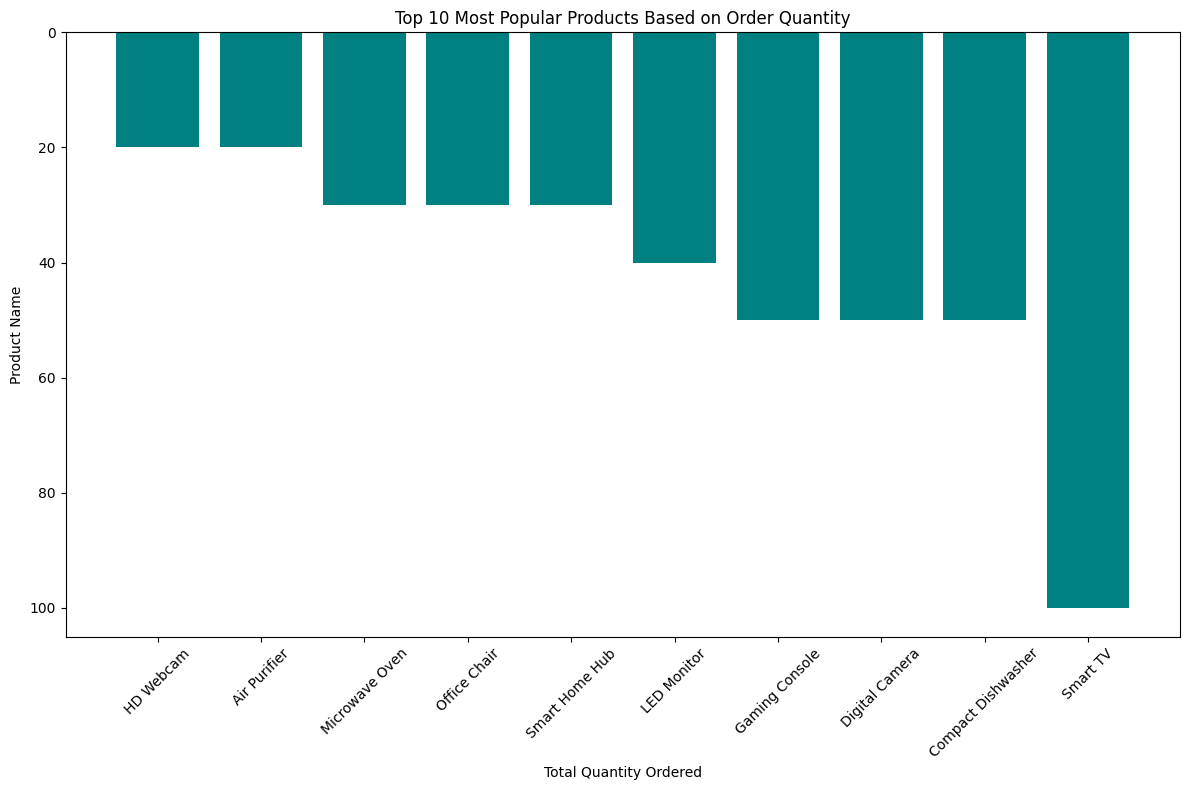

In [335]:
# Identify the most profitable products based on the difference between original and selling prices.

query = """
select 
    product_id, (original_price-selling_price) as profit
from
    product
order by
    profit desc
limit 10;
"""
df_profitable =  pd.read_sql(query, conn)

product_names_query = """
select
    product_id,
    product_name
from
    product;
"""
df_product_names = pd.read_sql(product_names_query, conn)
df_profitable = df_profitable.merge(df_product_names, on = 'product_id')

plt.figure(figsize=(12, 8))
plt.bar(df_profitable['product_name'], df_profitable['profit'], color='teal')
plt.xlabel('Total Quantity Ordered')
plt.ylabel('Product Name')
plt.xticks(rotation = 45)
plt.title('Top 10 Most Popular Products Based on Order Quantity')
plt.gca().invert_xaxis() 
plt.gca().invert_yaxis()
plt.tight_layout()

# Show the plot
plt.show()

C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\447922410.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  highest_quantity_df = pd.read_sql(highest_quantity_query, conn)
C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\447922410.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lowest_quantity_df = pd.read_sql(lowest_quantity_query, conn)


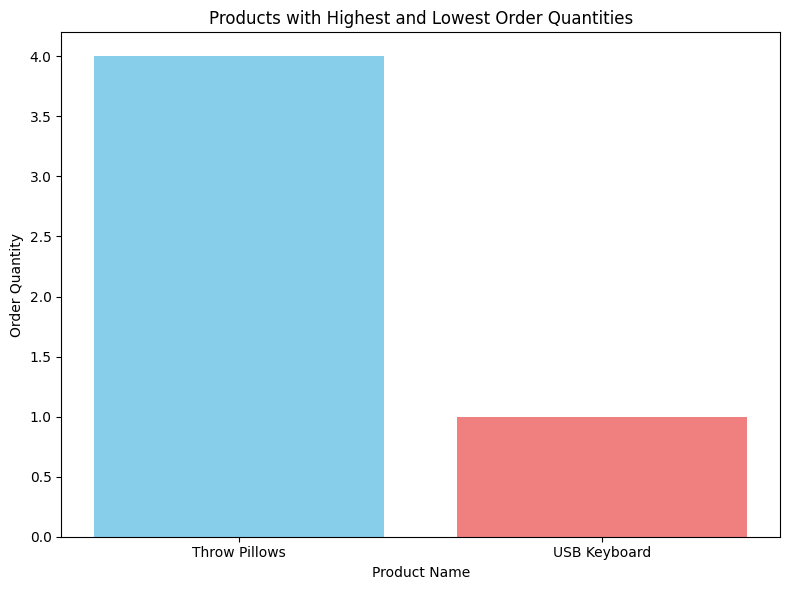

In [336]:
highest_quantity_query = """
SELECT 
    p.product_name,
    SUM(od.quantity) AS total_quantity
FROM 
    product p
JOIN 
    order_details od
ON 
    p.product_id = od.product_id
GROUP BY 
    p.product_name
ORDER BY 
    total_quantity DESC
LIMIT 1;
"""

# Query for the product with the lowest order quantity
lowest_quantity_query = """
SELECT 
    p.product_name,
    SUM(od.quantity) AS total_quantity
FROM 
    product p
JOIN 
    order_details od
ON 
    p.product_id = od.product_id
GROUP BY 
    p.product_name
ORDER BY 
    total_quantity ASC
LIMIT 1;
"""

# Execute the queries and fetch the results
highest_quantity_df = pd.read_sql(highest_quantity_query, conn)
lowest_quantity_df = pd.read_sql(lowest_quantity_query, conn)

# Combine the data for plotting
combined_df = pd.concat([highest_quantity_df, lowest_quantity_df], ignore_index=True)

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(combined_df['product_name'], combined_df['total_quantity'], color=['skyblue', 'lightcoral'])
plt.ylabel('Order Quantity')
plt.xlabel('Product Name')
plt.title('Products with Highest and Lowest Order Quantities')
plt.tight_layout()

# Show the plot
plt.show()

# Close the connection
# conn.close()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\515172078.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  highest_quantity_df = pd.read_sql(highest_quantity_query, conn)
C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\515172078.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lowest_quantity_df = pd.read_sql(lowest_quantity_query, conn)


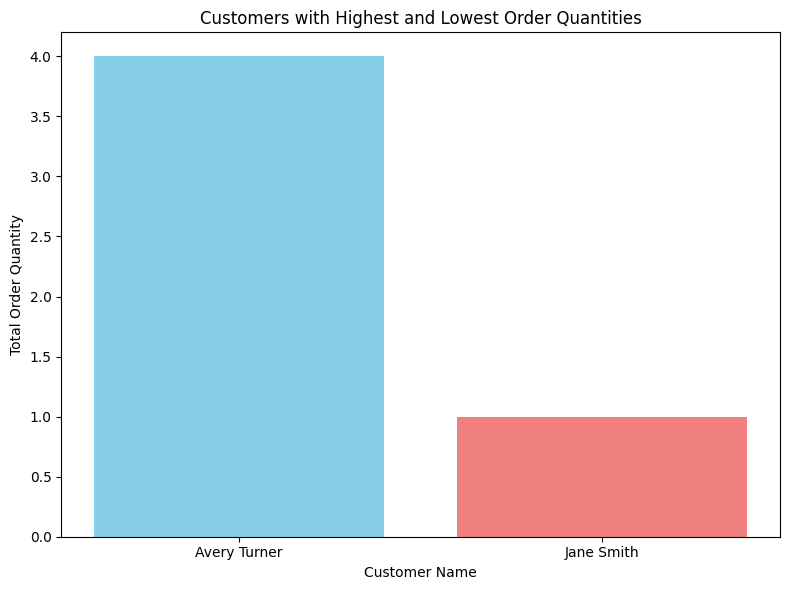

In [337]:
highest_quantity_query = """
SELECT 
    c.name,
    SUM(od.quantity) AS total_quantity
FROM 
    customer c
JOIN 
    order_details od
ON 
    c.customer_id = od.customer_id
GROUP BY 
    c.name
ORDER BY 
    total_quantity DESC
LIMIT 1;
"""

# Query for the customer with the lowest order quantity
lowest_quantity_query = """
SELECT 
    c.name,
    SUM(od.quantity) AS total_quantity
FROM 
    customer c
JOIN 
    order_details od
ON 
    c.customer_id = od.customer_id
GROUP BY 
    c.name
ORDER BY 
    total_quantity ASC
LIMIT 1;
"""

# Fetch the data into DataFrames
highest_quantity_df = pd.read_sql(highest_quantity_query, conn)
lowest_quantity_df = pd.read_sql(lowest_quantity_query, conn)

# Combine the data for plotting
combined_df = pd.concat([highest_quantity_df, lowest_quantity_df], ignore_index=True)

# Plotting the data
plt.figure(figsize=(8, 6))
plt.bar(combined_df['name'], combined_df['total_quantity'], color=['skyblue', 'lightcoral'])
plt.ylabel('Total Order Quantity')
plt.xlabel('Customer Name')
plt.title('Customers with Highest and Lowest Order Quantities')
plt.tight_layout()

# Show the plot
plt.show()

C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\867620002.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_payment_modes = pd.read_sql(query, conn)


  payment_mode  count
0  Credit Card     14
1       PayPal     14
2   Debit Card     12


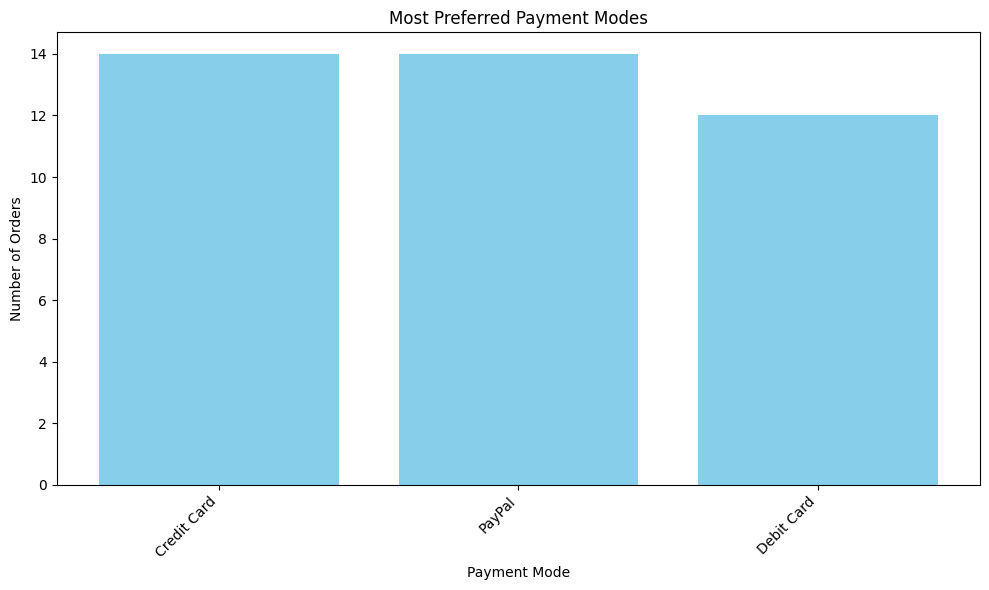

In [338]:
query = """
SELECT 
    payment_mode, 
    COUNT(*) AS count
FROM 
    order_details
GROUP BY 
    payment_mode
ORDER BY 
    count DESC;
"""

# Fetch the data into a DataFrame
df_payment_modes = pd.read_sql(query, conn)
print(df_payment_modes)

# Plotting the data
plt.figure(figsize=(10, 6))
plt.bar(df_payment_modes['payment_mode'], df_payment_modes['count'], color='skyblue')
plt.xlabel('Payment Mode')
plt.ylabel('Number of Orders')
plt.title('Most Preferred Payment Modes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\3623485688.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly_sales = pd.read_sql(query, conn)


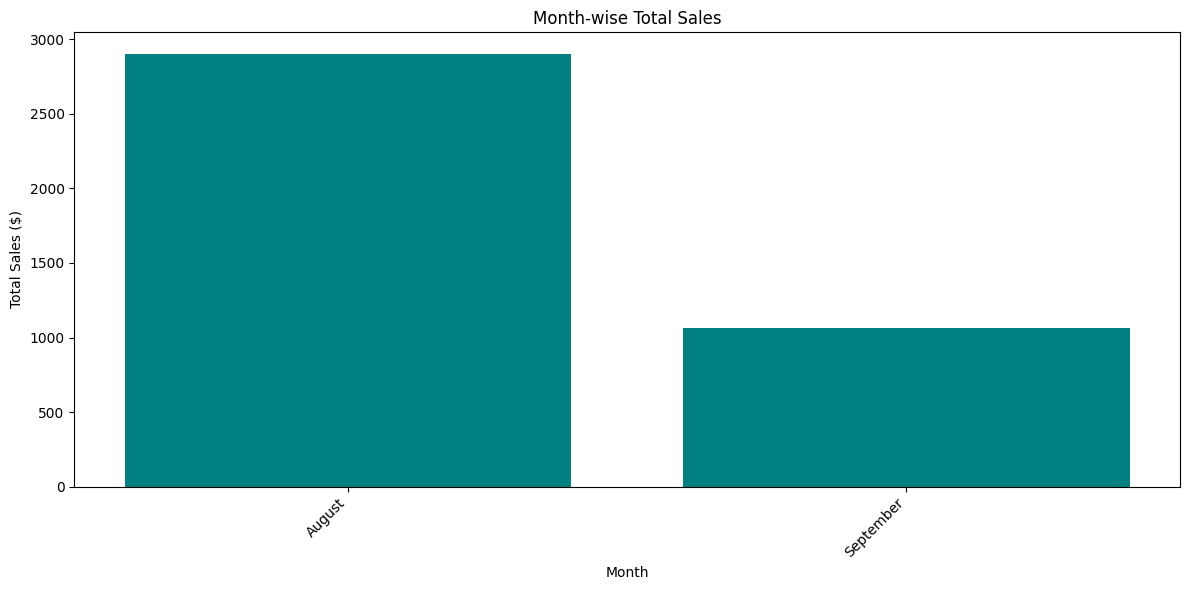

In [339]:
query = """
SELECT 
    DATE_FORMAT(order_date, '%Y-%m') AS order_month,
    DATE_FORMAT(order_date, '%M') AS month_name,
    SUM(total_price) AS total_sales
FROM 
    order_details
GROUP BY 
    order_month, month_name
ORDER BY 
    order_month;
"""

# Fetch the data into a DataFrame
df_monthly_sales = pd.read_sql(query, conn)


# Plotting the data
plt.figure(figsize=(12, 6))
plt.bar(df_monthly_sales['month_name'], df_monthly_sales['total_sales'], color='teal')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Month-wise Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\3247273957.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly_sales = pd.read_sql(query, conn)


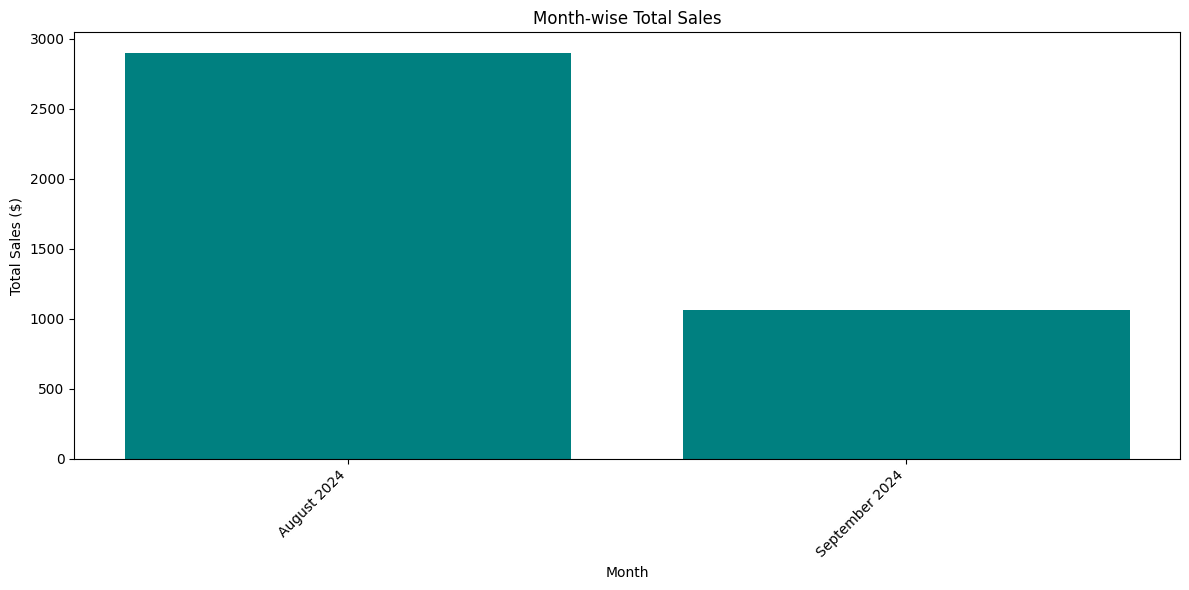

In [340]:
query = """
SELECT 
    DATE_FORMAT(order_date, '%Y-%m') AS order_month,
    DATE_FORMAT(order_date, '%M %Y') AS month_year_name,
    SUM(total_price) AS total_sales
FROM 
    order_details
GROUP BY 
    order_month, month_year_name
ORDER BY 
    order_month;
"""

# Fetch the data into a DataFrame
df_monthly_sales = pd.read_sql(query, conn)


# Plotting the data
plt.figure(figsize=(12, 6))
plt.bar(df_monthly_sales['month_year_name'], df_monthly_sales['total_sales'], color='teal')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Month-wise Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\1312880236.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales_by_date = pd.read_sql(query, conn)


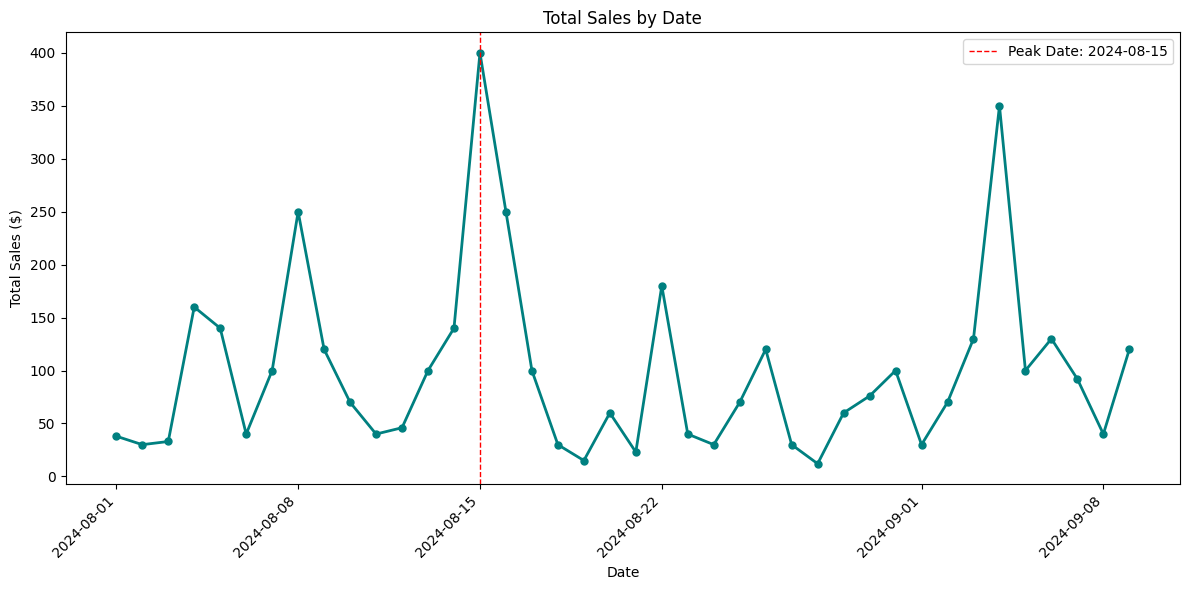

In [341]:
query = """
SELECT 
    DATE(order_date) AS order_date,
    SUM(total_price) AS total_sales
FROM 
    order_details
GROUP BY 
    DATE(order_date)
ORDER BY 
    order_date;
"""

# Fetch the data into a DataFrame
df_sales_by_date = pd.read_sql(query, conn)

# Find the peak order date
peak_date = df_sales_by_date.loc[df_sales_by_date['total_sales'].idxmax()]

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df_sales_by_date['order_date'], df_sales_by_date['total_sales'], marker='o', color='teal', linestyle='-', linewidth=2, markersize=5)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.title('Total Sales by Date')
plt.axvline(x=peak_date['order_date'], color='red', linestyle='--', linewidth=1, label=f'Peak Date: {peak_date["order_date"].strftime("%Y-%m-%d")}')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\3786114197.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_city_distribution = pd.read_sql(query, conn)


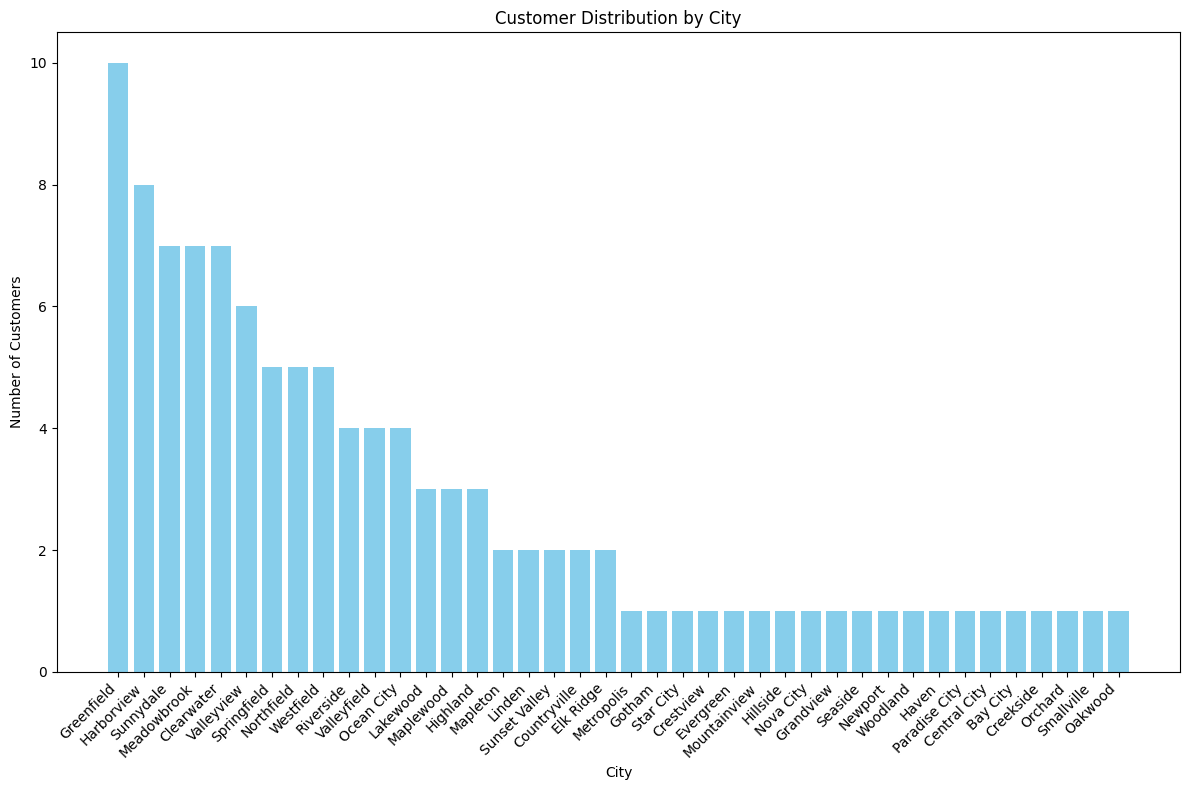

In [342]:
# customer distribution by city
query = """
SELECT 
    city,
    COUNT(*) AS number_of_customers
FROM 
    customer
GROUP BY 
    city
ORDER BY 
    number_of_customers DESC;
"""

# Fetch the data into a DataFrame
df_city_distribution = pd.read_sql(query, conn)

# Plot the distribution
plt.figure(figsize=(12, 8))
plt.bar(df_city_distribution['city'], df_city_distribution['number_of_customers'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by City')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\1607391841.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product = pd.read_sql(product_query, conn)
C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\1607391841.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category = pd.read_sql(category_query, conn)


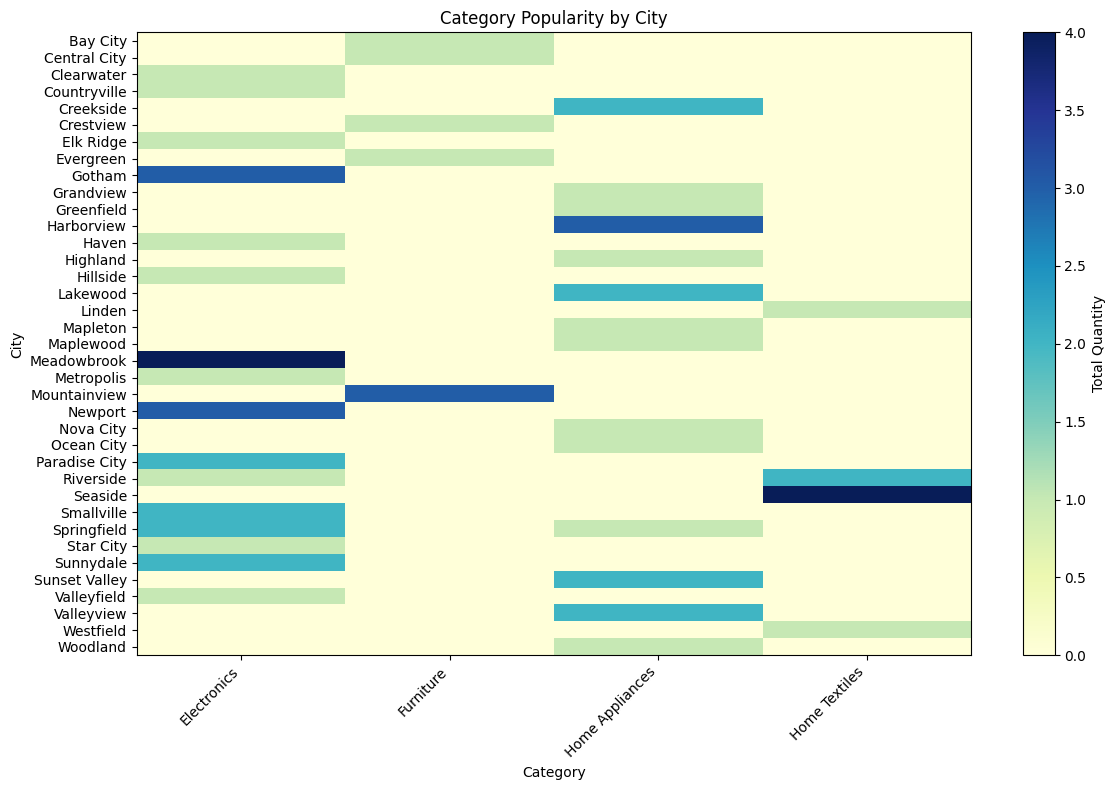

In [343]:
import numpy as np

category_query = """
SELECT
    c.city,
    p.category,
    SUM(od.quantity) AS total_quantity
FROM
    order_details od
JOIN
    product p ON od.product_id = p.product_id
JOIN
    customer c ON od.customer_id = c.customer_id
GROUP BY
    c.city, p.category;
"""

# Fetch data into DataFrames
df_product = pd.read_sql(product_query, conn)
df_category = pd.read_sql(category_query, conn)

# Pivot data for heatmaps
product_pivot = df_product.pivot_table(index='city', columns='product_name', values='total_quantity', aggfunc='sum', fill_value=0)
category_pivot = df_category.pivot_table(index='city', columns='category', values='total_quantity', aggfunc='sum', fill_value=0)

# Plot heatmap for category popularity by city
plt.figure(figsize=(12, 8))
plt.imshow(category_pivot, cmap='YlGnBu', aspect='auto')
plt.colorbar(label='Total Quantity')
plt.title('Category Popularity by City')
plt.xlabel('Category')
plt.ylabel('City')
plt.xticks(ticks=np.arange(len(category_pivot.columns)), labels=category_pivot.columns, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(category_pivot.index)), labels=category_pivot.index)
plt.tight_layout()
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\76792284.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_best_selling = pd.read_sql(best_selling_query, conn)


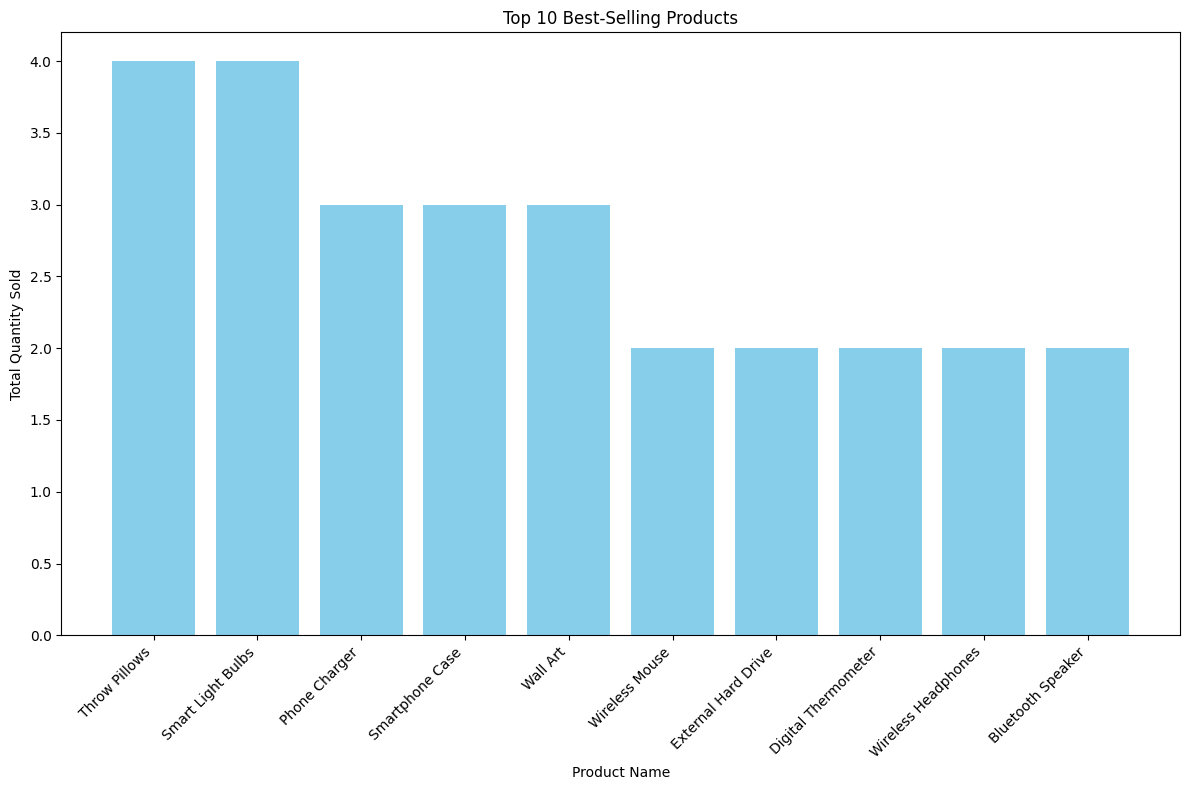

In [344]:
best_selling_query = """
SELECT
    p.product_name,
    SUM(od.quantity) AS total_quantity
FROM
    order_details od
JOIN
    product p ON od.product_id = p.product_id
GROUP BY
    p.product_name
ORDER BY
    total_quantity DESC
LIMIT 10;
"""

# Fetch data into a DataFrame
df_best_selling = pd.read_sql(best_selling_query, conn)

# Plotting the best-selling products
plt.figure(figsize=(12, 8))
plt.bar(df_best_selling['product_name'], df_best_selling['total_quantity'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.title('Top 10 Best-Selling Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2916395273.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_slow_moving = pd.read_sql(slow_moving_query, conn)


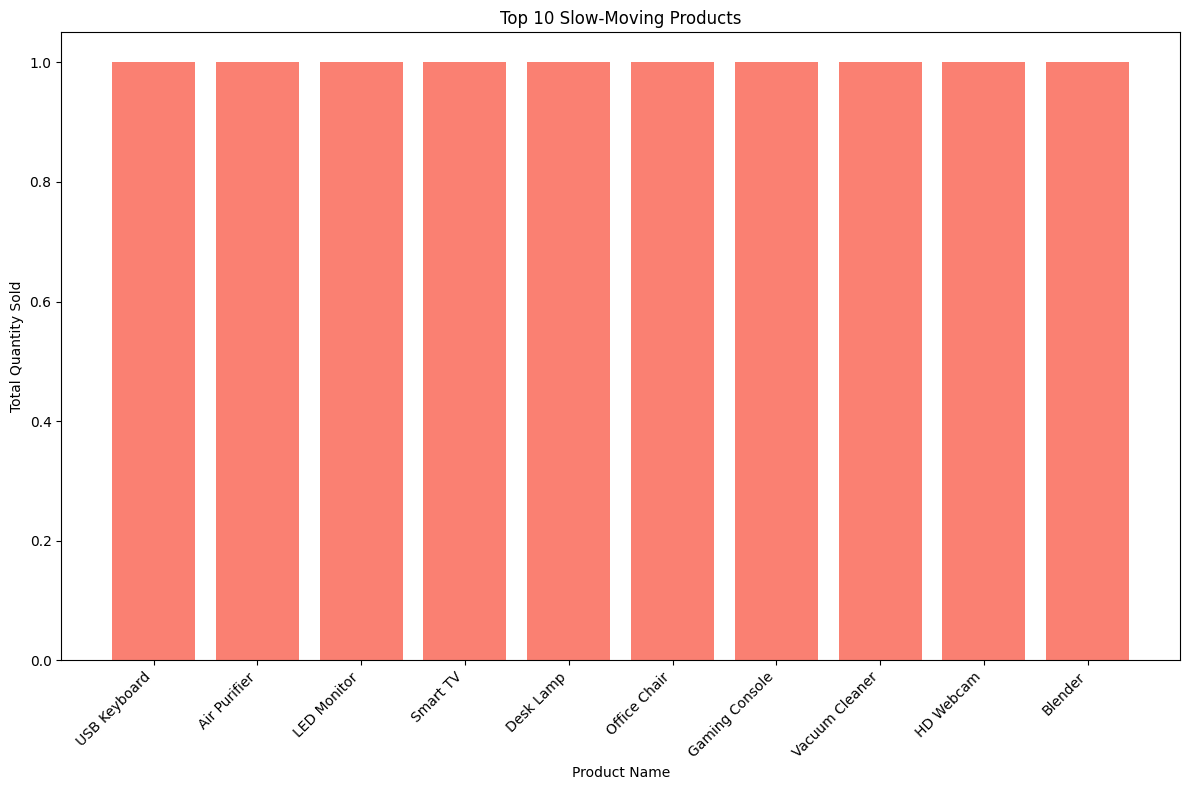

In [345]:
slow_moving_query = """
SELECT
    p.product_name,
    SUM(od.quantity) AS total_quantity
FROM
    order_details od
JOIN
    product p ON od.product_id = p.product_id
GROUP BY
    p.product_name
ORDER BY
    total_quantity ASC
LIMIT 10;
"""

# Fetch data into a DataFrame
df_slow_moving = pd.read_sql(slow_moving_query, conn)

# Plotting the slow-moving products
plt.figure(figsize=(12, 8))
plt.bar(df_slow_moving['product_name'], df_slow_moving['total_quantity'], color='salmon')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.title('Top 10 Slow-Moving Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\pkash\AppData\Local\Temp\ipykernel_9260\2775614476.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_status = pd.read_sql(status_query, conn)


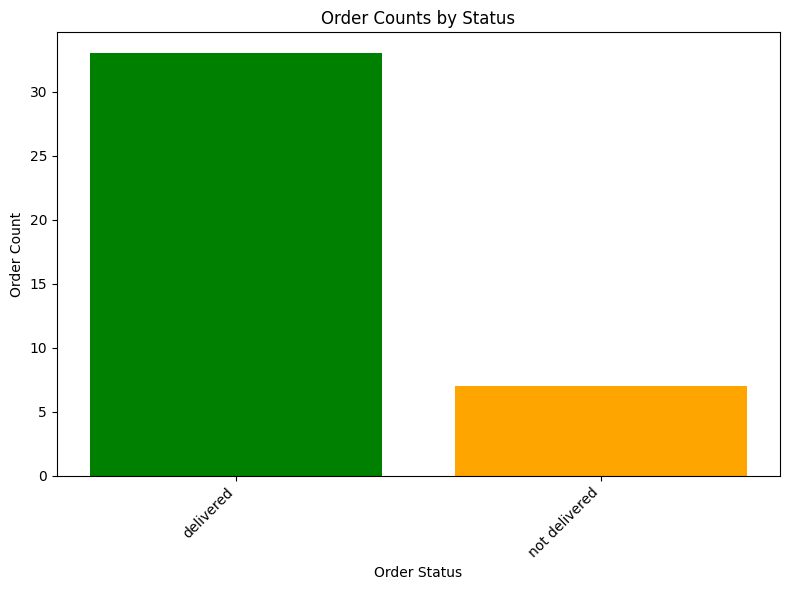

In [346]:
status_query = """
SELECT
    order_status,
    COUNT(*) AS order_count
FROM
    order_details
GROUP BY
    order_status;
"""

# Fetch data into a DataFrame
df_status = pd.read_sql(status_query, conn)

# Plotting the order counts by status
plt.figure(figsize=(8, 6))
plt.bar(df_status['order_status'], df_status['order_count'], color=['green', 'orange'])
plt.xlabel('Order Status')
plt.ylabel('Order Count')
plt.title('Order Counts by Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
